In [1]:
import numpy as np
from desc.objectives import TrappedResonance
from desc.equilibrium import Equilibrium
import matplotlib.pyplot as plt

In [3]:
eq = Equilibrium.load("precise_QA_output.h5")[-1]

num_eta = 20
Ekin_frac = 1e-5
s_min = 0.08
s_max = 0.12
pp = 1
qq = 2
num_pitch = 2

data = np.load("poincare_data_Bcrit_0.98.npz")

pitch_invs = np.linspace(1/data['lam'][()],1.09,num_pitch)
rhos = np.linspace(s_min**0.5,s_max**0.5,10)
# s_prof = np.linspace(s_min, s_max, 10)
# rhos = np.sqrt(s_prof)


obj = TrappedResonance(
    eq, 
    rho=rhos, 
    num_eta=num_eta, 
    M=1, 
    N=0,
    n_max=2,
    DEBUG=True,
    wd_blur=1.2,
    pitch_invs=pitch_invs,
    pitch_method=2, 
    num_pitch=num_pitch,
    num_well=1, 
    num_transit=8,
    knots_per_transit=100, 
    num_quad=48, 
    KE_frac=np.array([Ekin_frac]),
    STAB_SACRIFICE=False, # True = sacrifice Omega_eta' for numerical stability,
    bt_filter_flag=False,
    rt_filter_flag=False,
    CONSERVATIVE_IW=False, # which island width function, True = conservative version

)
obj.build()
val = obj.compute(eq.params_dict)

Precomputing transforms


In [4]:
# Resonance array information
res_arr = val['res_arr']
print(res_arr)
i_res = 3
print(res_arr[i_res])

[ 0.          1.         -1.          0.5        -0.5         2.
 -2.          3.         -3.          1.5        -1.5         4.
 -4.          2.5        -2.5         3.5        -3.5         3.14159265
  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265
  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265
  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265
  3.14159265  3.14159265  3.14159265  3.14159265  3.14159265]
0.5


In [5]:
# np.savez("desc_debug.npz", val=val)
val = np.load("desc_debug.npz",allow_pickle=True)['val'][()]
valid = np.isfinite(val['Delta_s_4'][0,0,:])
Delta_s_4 = val['Delta_s_4'][:,0,0,i_res]
# s_res = val['s_res'][valid]
# p_arr = val['m_arr'][valid]
q_arr = val['q_arr']
Omega = val['omega_arr'][:,0,0]

In [6]:
Bcrit = 1/data['lam'][()]
freq_data = np.load("trapped_frequencies.npz",allow_pickle=True)

omega_b = freq_data['omega_b_prof'][()]
omega_zeta = freq_data['omega_zeta_prof'][()]

Omega_firm3d = 2 * omega_zeta/omega_b
lam_values = freq_data['lam_values'][()]
lam_index = np.argmin(np.abs(1/lam_values - Bcrit))
Omega_firm3d = Omega_firm3d[lam_index]
s_firm3d = freq_data['s_prof'][()][lam_index]


<>:7: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_1996951/3957844954.py:7: SyntaxWarning: invalid escape sequence '\O'
  plt.ylabel('$\Omega$')


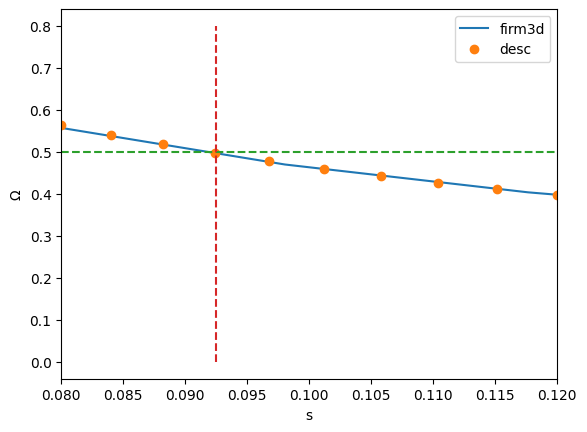

In [6]:
plt.figure()
plt.plot(s_firm3d,Omega_firm3d,'-',label='firm3d')
plt.plot(rhos**2,Omega,'o',label='desc')
plt.plot([0.08,0.12],[0.5,0.5],'--')
plt.plot([0.0925,0.0925],[0.0,0.8],'--')
plt.xlabel('s')
plt.ylabel('$\Omega$')
plt.xlim(s_min,s_max)
plt.legend()
plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_1725947/1836500613.py:16: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\eta$',fontsize=16)


[0.00904327 0.01043501 0.01031051 0.01098422 0.0101567  0.00894494
 0.00823581 0.00655298 0.00548802 0.00653707]


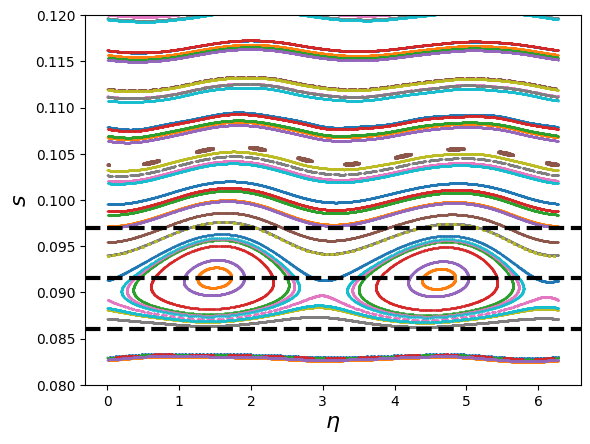

<Figure size 640x480 with 0 Axes>

In [11]:
s_poinc = data['s_all']
etas_poinc = np.mod(data['etas_all'], 2*np.pi)


Delta_s = 4 * (Delta_s_4) ** (1/4)

print(Delta_s)

fig,ax = plt.subplots()
for i in range(len(s_poinc)):
    plt.scatter(etas_poinc[i],s_poinc[i],s=0.1)
plt.ylim(s_min,s_max)
plt.axhline([0.0915], color='k', linestyle='--',linewidth=3)
plt.axhline([0.0915+Delta_s[3]/2], color='k', linestyle='--',linewidth=3)
plt.axhline([0.0915-Delta_s[3]/2], color='k', linestyle='--',linewidth=3)
plt.xlabel('$\eta$',fontsize=16)
plt.ylabel('$s$',fontsize=16)
plt.show()
ax.tick_params(axis='both', labelsize=15)
plt.savefig('iw_preciseQA_Bc0.98_1_2.pdf')